## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- IMPORT FROM OTHER FILES
import sys
import os

# Set the path to the package: relativistic degrees of freedom
project_root = os.path.abspath("../..")  # or maybe "../.." or "." depending on notebook location
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
from relativistic_dof import RelativisticDOFRegistry

## First implementation of Relativistic DOF (Table or from 1609.04979)

In [3]:
# --- Initialize the class ---
RelativisticDOF = RelativisticDOFRegistry.get_method("table")

# ------------------------------ CHECK: AXION MASS IN ONE PRECESS (MUON SCATTERING) -------------------------------------------- #
# Typical range of axion mass
muon_mass = 105.66*10**6  # [eV]
muon_mass_MeV = 105.66  # [MeV]
x_dec_muon = 30  # decouple from the plasma
kB_T_today = 8.617 * 10**(-5) * 2.725  # kB * T, [kB*T] = [kB] * [T] = [eV/K] * [K] = [eV]

# calculate decoupling dof
axion_decouple_dof = RelativisticDOF.compute_decoupling_dof(muon_mass, x_dec_muon)
g_s_today = RelativisticDOF.get_degrees_of_freedom(kB_T_today, dof_type="g_eff_s")
T_dec_muon = RelativisticDOF.compute_decoupling_temperature(muon_mass, x_dec_muon)
print(f"muon mass: {muon_mass_MeV} [MeV], corresponds to: {axion_decouple_dof} relativistic dof of entropy")
print(f"Today corresponds to: {g_s_today} relativistic dof of entropy")
print(f"Decouple temperatures corresponds to: {T_dec_muon*10**(-6)} MeV")

muon mass: 105.66 [MeV], corresponds to: 10.728419649115382 relativistic dof of entropy
Today corresponds to: 3.91 relativistic dof of entropy
Decouple temperatures corresponds to: 3.522 MeV


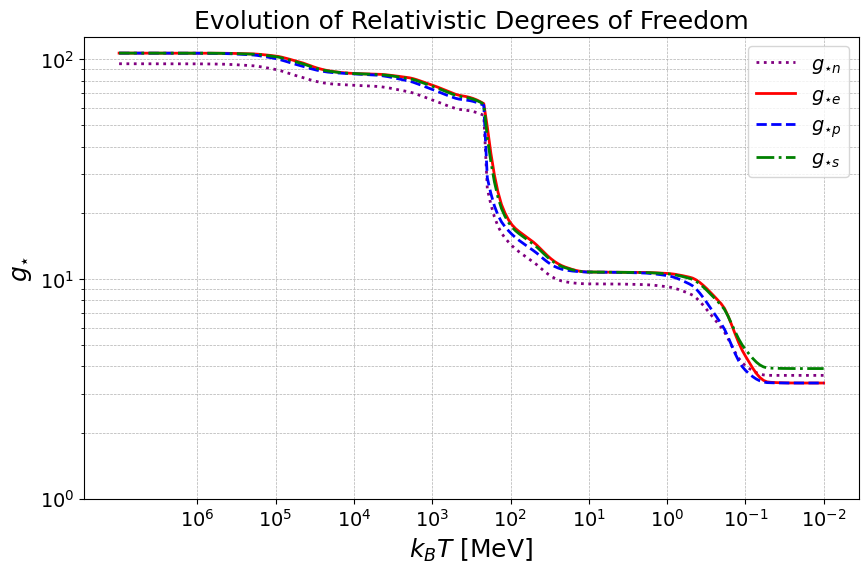

In [4]:
# ------------------------------ PLOT FROM: 1609.04979 ----------------------------------------------------------- #
# Get the range of kB*T values
min_kBT = RelativisticDOF.get_min_kB_T()
max_kBT = RelativisticDOF.get_max_kB_T()

# Generate kB_T values for plotting in MeV
kB_T_values = np.logspace(np.log10(min_kBT), np.log10(max_kBT), 200)
kB_T_values_MeV = kB_T_values / 1e6  # Convert eV to MeV

# Compute interpolated values
g_n_values = RelativisticDOF.get_degrees_of_freedom(kB_T_values, dof_type="g_eff_n")
g_e_values = RelativisticDOF.get_degrees_of_freedom(kB_T_values, dof_type="g_eff_e")
g_p_values = RelativisticDOF.get_degrees_of_freedom(kB_T_values, dof_type="g_eff_p")
g_s_values = RelativisticDOF.get_degrees_of_freedom(kB_T_values, dof_type="g_eff_s")

# Create the plot with improved formatting
plt.figure(figsize=(10, 6))

# Plot all degrees of freedom
plt.plot(kB_T_values_MeV[::-1], g_n_values[::-1], label=r"$g_{\star n}$", linestyle=":", linewidth=2,
         color="purple")
plt.plot(kB_T_values_MeV[::-1], g_e_values[::-1], label=r"$g_{\star e}$", linestyle="-", linewidth=2, color="red")
plt.plot(kB_T_values_MeV[::-1], g_p_values[::-1], label=r"$g_{\star p}$", linestyle="--", linewidth=2, color="blue")
plt.plot(kB_T_values_MeV[::-1], g_s_values[::-1], label=r"$g_{\star s}$", linestyle="-.", linewidth=2,
         color="green")

# Log scale for both axes
plt.xscale("log")
plt.yscale("log")

# Axis labels and title
plt.xlabel(r"$k_B T$ [MeV]", fontsize=18)
plt.ylabel(r"$g_{\star}$", fontsize=18)
plt.title(r"Evolution of Relativistic Degrees of Freedom", fontsize=18)

# Invert x-axis so that higher temperatures are on the left, lower on the right
plt.gca().invert_xaxis()

# Set properly formatted log ticks for x-axis (kB*T in MeV)
x_ticks = [10 ** i for i in range(6, -3, -1)]  # 10^6 to 10^-2
plt.xticks(x_ticks, [rf"$10^{{{int(np.log10(tick))}}}$" for tick in x_ticks], fontsize=14)

# Set properly formatted log ticks for y-axis (Degrees of Freedom)
y_ticks = [1, 10, 100]
plt.yticks(y_ticks, [rf"$10^{{{int(np.log10(tick))}}}$" for tick in y_ticks], fontsize=14)

# Add grid lines
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# Show legend
plt.legend(fontsize=14)

# Display the plot
plt.show()

## Second implementation of Relativistic DOF (FitFunction or from 1803.01038)

In [5]:
# --- Initialize the class ---
RelativisticDOF = RelativisticDOFRegistry.get_method("fit")

# ------------------------------ CHECK: AXION MASS IN ONE PRECESS (MUON SCATTERING) -------------------------------------------- #
# Typical range of axion mass
muon_mass = 105.66*10**6  # [eV]
muon_mass_MeV = 105.66  # [MeV]
x_dec_muon = 30  # decouple from the plasma
kB_T_today = 8.617 * 10**(-5) * 2.725  # kB * T, [kB*T] = [kB] * [T] = [eV/K] * [K] = [eV]

# calculate decoupling dof
axion_decouple_dof = RelativisticDOF.compute_decoupling_dof(muon_mass, x_dec_muon)
g_s_today = RelativisticDOF.get_degrees_of_freedom(kB_T_today, dof_type="g_eff_s")
T_dec_muon = RelativisticDOF.compute_decoupling_temperature(muon_mass, x_dec_muon)
print(f"muon mass: {muon_mass_MeV} [MeV], corresponds to: {axion_decouple_dof} relativistic dof of entropy")
print(f"Today corresponds to: {g_s_today} relativistic dof of entropy")
print(f"Decouple temperatures corresponds to: {T_dec_muon*10**(-6)} MeV")

muon mass: 105.66 [MeV], corresponds to: 10.718467662968656 relativistic dof of entropy
Today corresponds to: 3.931 relativistic dof of entropy
Decouple temperatures corresponds to: 3.522 MeV


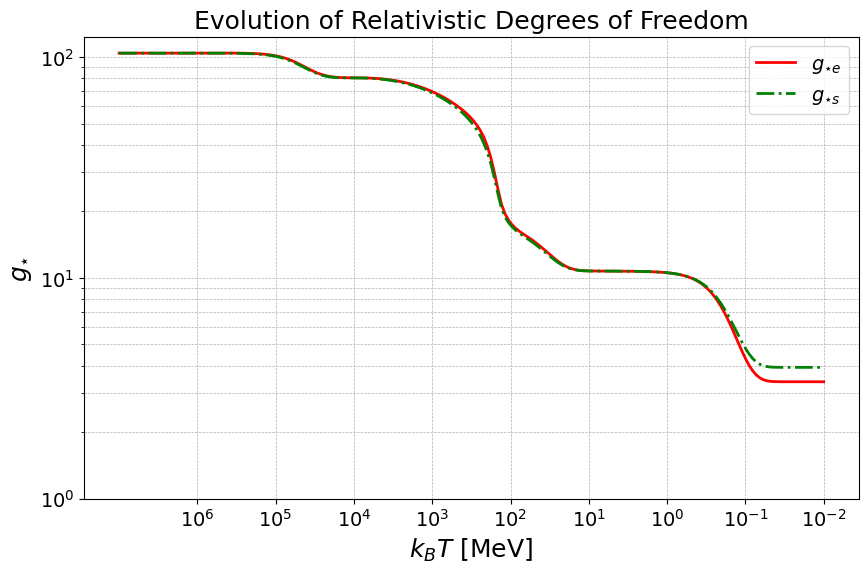

In [6]:
# ------------------------------ PLOT USING: 1609.04979 ---------------------------------------------------------- #
# --- Can be compared to the Figure 14 from 2108.05371
# ---------------------------------------------------------------------------------------------------------------- #
# Get the range of kB*T values
min_kBT = RelativisticDOF.get_min_kB_T()
max_kBT = RelativisticDOF.get_max_kB_T()

# Generate kB_T values for plotting in MeV
kB_T_values = np.logspace(np.log10(min_kBT), np.log10(max_kBT), 200)
kB_T_values_MeV = kB_T_values / 1e6  # Convert eV to MeV

# Compute interpolated values
g_e_values = RelativisticDOF.get_degrees_of_freedom(kB_T_values, dof_type="g_eff_e")
g_s_values = RelativisticDOF.get_degrees_of_freedom(kB_T_values, dof_type="g_eff_s")

# Create the plot with improved formatting
plt.figure(figsize=(10, 6))

# Plot all degrees of freedom
plt.plot(kB_T_values_MeV[::-1], g_e_values[::-1], label=r"$g_{\star e}$", linestyle="-", linewidth=2, color="red")
plt.plot(kB_T_values_MeV[::-1], g_s_values[::-1], label=r"$g_{\star s}$", linestyle="-.", linewidth=2, color="green")

# Log scale for both axes
plt.xscale("log")
plt.yscale("log")

# Axis labels and title
plt.xlabel(r"$k_B T$ [MeV]", fontsize=18)
plt.ylabel(r"$g_{\star}$", fontsize=18)
plt.title(r"Evolution of Relativistic Degrees of Freedom", fontsize=18)

# Invert x-axis so that higher temperatures are on the left, lower on the right
plt.gca().invert_xaxis()

# Set properly formatted log ticks for x-axis (kB*T in MeV)
x_ticks = [10 ** i for i in range(6, -3, -1)]  # 10^6 to 10^-2
plt.xticks(x_ticks, [rf"$10^{{{int(np.log10(tick))}}}$" for tick in x_ticks], fontsize=14)

# Set properly formatted log ticks for y-axis (Degrees of Freedom)
y_ticks = [1, 10, 100]
plt.yticks(y_ticks, [rf"$10^{{{int(np.log10(tick))}}}$" for tick in y_ticks], fontsize=14)

# Add grid lines
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# Show legend
plt.legend(fontsize=14)

# Display the plot
plt.show()

## Third implementation of Relativistic DOF (Lattice or from 1606.07494)

In [7]:
# --- Initialize the class ---
RelativisticDOF = RelativisticDOFRegistry.get_method("lattice")

# ------------------------------ CHECK: AXION MASS IN ONE PRECESS (MUON SCATTERING) -------------------------------------------- #
# Typical range of axion mass
muon_mass = 105.66*10**6  # [eV]
muon_mass_MeV = 105.66  # [MeV]
x_dec_muon = 30  # decouple from the plasma
kB_T_today = 8.617 * 10**(-5) * 2.725  # kB * T, [kB*T] = [kB] * [T] = [eV/K] * [K] = [eV]

# calculate decoupling dof
axion_decouple_dof = RelativisticDOF.compute_decoupling_dof(muon_mass, x_dec_muon)
g_s_today = RelativisticDOF.get_degrees_of_freedom(kB_T_today, dof_type="g_eff_s")
T_dec_muon = RelativisticDOF.compute_decoupling_temperature(muon_mass, x_dec_muon)
print(f"muon mass: {muon_mass_MeV} [MeV], corresponds to: {axion_decouple_dof} relativistic dof of entropy")
print(f"Today corresponds to: {g_s_today} relativistic dof of entropy")
print(f"Decouple temperatures corresponds to: {T_dec_muon*10**(-6)} MeV")

muon mass: 105.66 [MeV], corresponds to: 10.738715863368094 relativistic dof of entropy
Today corresponds to: [10.66342385] relativistic dof of entropy
Decouple temperatures corresponds to: 3.522 MeV


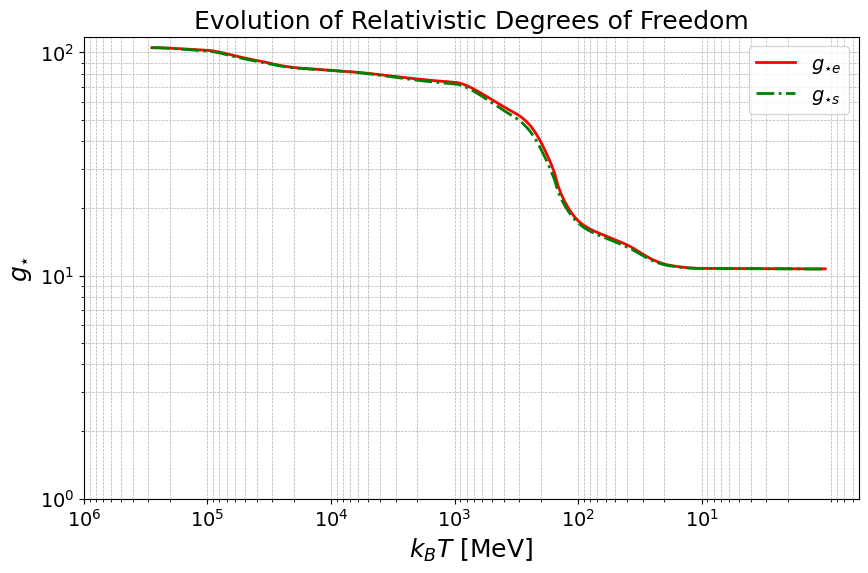

In [8]:
# ------------------------------ PLOT USING: 1606.07494 ---------------------------------------------------------- #
# Get the range of kB*T values
min_kBT = RelativisticDOF.get_min_kB_T()
max_kBT = RelativisticDOF.get_max_kB_T()

# Generate kB_T values for plotting in MeV
kB_T_values = np.logspace(np.log10(min_kBT), np.log10(max_kBT), 200)
kB_T_values_MeV = kB_T_values / 1e6  # Convert eV to MeV

# Compute interpolated values
g_e_values = RelativisticDOF.get_degrees_of_freedom(kB_T_values, dof_type="g_eff_e")
g_s_values = RelativisticDOF.get_degrees_of_freedom(kB_T_values, dof_type="g_eff_s")

# Create the plot with improved formatting
plt.figure(figsize=(10, 6))

# Plot all degrees of freedom
plt.plot(kB_T_values_MeV[::-1], g_e_values[::-1], label=r"$g_{\star e}$", linestyle="-", linewidth=2, color="red")
plt.plot(kB_T_values_MeV[::-1], g_s_values[::-1], label=r"$g_{\star s}$", linestyle="-.", linewidth=2, color="green")

# Log scale for both axes
plt.xscale("log")
plt.yscale("log")

# Axis labels and title
plt.xlabel(r"$k_B T$ [MeV]", fontsize=18)
plt.ylabel(r"$g_{\star}$", fontsize=18)
plt.title(r"Evolution of Relativistic Degrees of Freedom", fontsize=18)

# Invert x-axis so that higher temperatures are on the left, lower on the right
plt.gca().invert_xaxis()

# Set properly formatted log ticks for x-axis (kB*T in MeV)
x_ticks = [10 ** i for i in range(6, 0, -1)]  # 10^6 to 10^0
plt.xticks(x_ticks, [rf"$10^{{{int(np.log10(tick))}}}$" for tick in x_ticks], fontsize=14)

# Set properly formatted log ticks for y-axis (Degrees of Freedom)
y_ticks = [1, 10, 100]
plt.yticks(y_ticks, [rf"$10^{{{int(np.log10(tick))}}}$" for tick in y_ticks], fontsize=14)

# Add grid lines
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# Show legend
plt.legend(fontsize=14)

# Display the plot
plt.show()